# 🎯 01-数据结构与算法 · 主题 5：二分查找

> 二分是**唯一能在有序/可判定结构上达到 $O(\log n)$** 的经典算法，也是手撕题最爱的考点。
> 本 notebook 目标：**吃透三种模板与循环不变量 → 掌握边界二分 → 吃透 7 道高频题 → 通过 25 道自测**。

**前置**：主题 1-4。**运行环境**：Python 3.8+，无第三方依赖（会对照 `bisect` 标准库）。

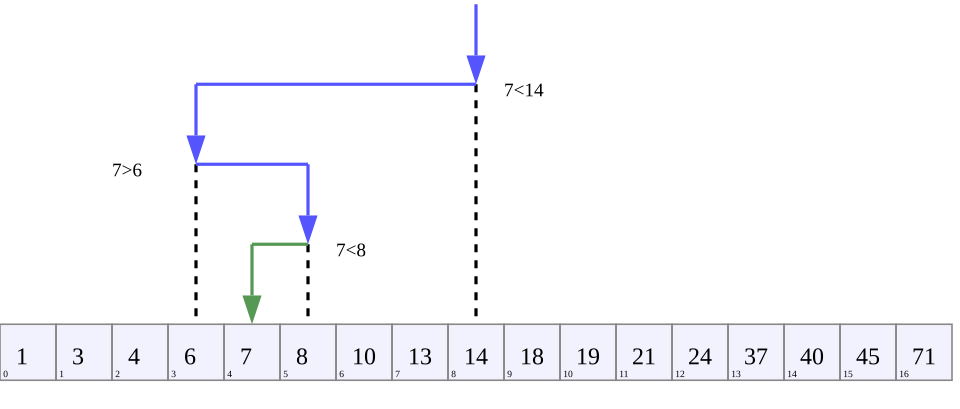

> 📷 二分查找：每次与中点比较，区间折半，O(log n)
> *图源：Wikimedia Commons（开放授权）*


### 猜数字类比：二分到底在干嘛

玩过「1~100 猜数字」吗？每次都**猜中间数**，对方只告诉你大了 / 小了 / 对了，最多 $\lceil \log_2 100 \rceil = 7$ 次必中——这就是二分查找的生活原型：

- **单调性**：数轴上的大小关系是单调的，「猜的数 > 答案」和「猜的数 < 答案」把候选区间一分为二；
- **每次排除一半**：无论猜大猜小，剩余区间都减半，步数是 $\log_2 N$ 级；
- **判定函数**：`mid` 大了还是小了，本质上就是后面「值域二分」的雏形（答案范围二分）。

记住这个画面：**二分 = 不断回答「大了还是小了」，把不可能的一半扔掉**。后面所有模板、边界、旋转数组、值域二分，都是这一句话的变体。


## §1 二分前提与心智模型

### 什么时候能用二分（两个条件）

1. **有序**：数组有序（或按某种规则排列）
2. **可判定单调性**：存在一个判定函数 $f(mid)$，答案是「某条件首次/最后成立」的位置——单调序列上可行

> 💡 现代二分题很多是**值域二分**（答案在数值范围上二分，如 875、1011），而非直接对数组二分。

### 循环不变量（背下来）

每种模板都要明确：**循环过程中，答案一定在区间 $[l, r]$ 内**（或 $[l, r)$ 内）。写对不变量，边界就写不错。

### 复杂度公式

每次迭代排除一半：

$$T(n) = T\left(\frac{n}{2}\right) + O(1) \implies T(n) = O(\log n)$$

**为什么 mid 要写 `l + (r - l) // 2`**：`(l + r) // 2` 在 $l + r$ 溢出时出错（C++/Java 面试必问），Python 无溢出但为统一习惯也这样写。

## §2 标准模板（闭区间 [l, r]，LeetCode 704）

**循环不变量**：若 target 存在，其下标必在 $[l, r]$ 内。

$$\text{while } l \le r: \quad mid = l + \lfloor (r - l)/2 \rfloor$$

- $a[mid] < target$ → target 在右侧 → $l = mid + 1$
- $a[mid] > target$ → target 在左侧 → $r = mid - 1$
- 相等 → 返回 mid；循环结束（$l > r$）→ 不存在

**为什么循环条件是 $l \le r$**：闭区间内只剩一个元素也要判断（mid 可取到 l = r）；`l < r` 会漏掉单元素区间。

> ⚠️ **死循环根源**：`mid` 永远取不到「不改变区间」的值。闭区间模板两边都 ±1，保证区间严格缩小。

In [ ]:
def binary_search(nums, target):
    l, r = 0, len(nums) - 1        # 闭区间 [l, r]
    while l <= r:
        mid = l + (r - l) // 2
        if nums[mid] == target:
            return mid
        elif nums[mid] < target:
            l = mid + 1            # 答案在右半
        else:
            r = mid - 1            # 答案在左半
    return -1

def search_insert(nums, target):
    # 返回第一个 >= target 的位置（即插入位置），左闭右开模板
    l, r = 0, len(nums)
    while l < r:
        mid = l + (r - l) // 2
        if nums[mid] < target:
            l = mid + 1
        else:
            r = mid
    return l

print('binary_search:', binary_search([-1, 0, 3, 5, 9, 12], 9))   # 期望 4
print('binary_search:', binary_search([-1, 0, 3, 5, 9, 12], 2))   # 期望 -1
print('binary_search:', binary_search([5], 5))                    # 期望 0
print('search_insert:', search_insert([1, 3, 5, 6], 5))           # 期望 2
print('search_insert:', search_insert([1, 3, 5, 6], 2))           # 期望 1
print('search_insert:', search_insert([1, 3, 5, 6], 7))           # 期望 4

## §3 边界模板：lower_bound / upper_bound（左闭右开）

**问题**：找第一个 $\ge target$ 的位置（lower_bound，即 Python `bisect_left`）与第一个 $> target$ 的位置（upper_bound，`bisect_right`）。

**左闭右开模板 $[l, r)$，循环不变量**：

$$\text{答案} \in [l, r), \quad a[l-1] < target \le a[r]$$

$$\text{while } l < r:\quad mid = l + \lfloor (r - l)/2 \rfloor$$

- $a[mid] < target$ → 答案在 $(mid, r)$ → $l = mid + 1$
- $a[mid] \ge target$ → 答案在 $[l, mid]$ → $r = mid$（**mid 不减 1**，因为 mid 可能就是答案）

**关键**：`r = mid` 而不是 `r = mid - 1`——这就是边界二分的灵魂：**mid 本身可能成立**，不能排除。

**应用**：

- 元素出现次数 = `upper_bound(t) - lower_bound(t)`
- 插入位置（35）= `lower_bound(target)`
- 第一个和最后一个位置（34）= lower_bound + upper_bound - 1

In [ ]:
from bisect import bisect_left, bisect_right

def lower_bound(a, target):
    # 第一个 >= target 的下标
    l, r = 0, len(a)
    while l < r:
        mid = l + (r - l) // 2
        if a[mid] < target:
            l = mid + 1
        else:
            r = mid              # mid 可能是答案，保留
    return l

def upper_bound(a, target):
    # 第一个 > target 的下标
    l, r = 0, len(a)
    while l < r:
        mid = l + (r - l) // 2
        if a[mid] <= target:
            l = mid + 1
        else:
            r = mid
    return l

a = [1, 2, 2, 2, 3, 5]
print('手写 lower_bound(2) =', lower_bound(a, 2), '，bisect_left =', bisect_left(a, 2))   # 1
print('手写 upper_bound(2) =', upper_bound(a, 2), '，bisect_right =', bisect_right(a, 2))  # 4
print('2 的出现次数 =', upper_bound(a, 2) - lower_bound(a, 2))                            # 3
print('lower_bound(4) =', lower_bound(a, 4), '（不存在，返回插入位置）')                    # 6

## §4 在排序数组中查找元素的第一个和最后一个位置（LeetCode 34）

**题目**：返回 target 在有序数组中的下标区间 $[first, last]$，不存在返回 $[-1, -1]$。

**公式（用边界二分组合）**：

$$first = \text{lower\_bound}(target), \quad last = \text{upper\_bound}(target) - 1$$

**校验**：$first \le last$ 且 $a[first] = target$ 才存在；否则返回 $[-1,-1]$。

**复杂度**：时间 $O(\log n)$，空间 $O(1)$。

In [ ]:
def search_range(nums, target):
    lo = lower_bound(nums, target)          # 第一个 >= target
    hi = upper_bound(nums, target) - 1      # 最后一个 <= target
    if lo <= hi and lo < len(nums) and nums[lo] == target:
        return [lo, hi]
    return [-1, -1]

print('test1:', search_range([5, 7, 7, 8, 8, 10], 8))    # 期望 [3, 4]
print('test2:', search_range([5, 7, 7, 8, 8, 10], 6))    # 期望 [-1, -1]
print('test3:', search_range([], 0))                     # 期望 [-1, -1]
print('test4:', search_range([2, 2], 2))                 # 期望 [0, 1]

## §5 搜索旋转排序数组（LeetCode 33）

**题目**：数组在某处旋转（如 `[0,1,2,4,5,6,7] → [4,5,6,7,0,1,2]`），找 target。

**关键观察**：二分后，**左半段或右半段至少有一段完全有序**：

$$a[l] \le a[mid] \implies \text{左半段 } [l, mid] \text{ 有序} \quad \text{否则右半段 } (mid, r] \text{ 有序}$$

**决策公式**（左半有序时）：

$$target \in [a[l], a[mid)) \implies r = mid - 1 \quad \text{否则} \quad l = mid + 1$$

（右半有序对称处理。）

**复杂度**：时间 $O(\log n)$，空间 $O(1)$。

> 💡 含重复值的版本（81）把判断改成 $a[l] == a[mid] == a[r]$ 时 `l += 1` 退化为 $O(n)$ 最坏。

In [ ]:
def search(nums, target):
    l, r = 0, len(nums) - 1
    while l <= r:
        mid = l + (r - l) // 2
        if nums[mid] == target:
            return mid
        if nums[l] <= nums[mid]:            # 左半段有序
            if nums[l] <= target < nums[mid]:
                r = mid - 1
            else:
                l = mid + 1
        else:                               # 右半段有序
            if nums[mid] < target <= nums[r]:
                l = mid + 1
            else:
                r = mid - 1
    return -1

print('test1:', search([4, 5, 6, 7, 0, 1, 2], 0))    # 期望 4
print('test2:', search([4, 5, 6, 7, 0, 1, 2], 3))    # 期望 -1
print('test3:', search([1], 0))                      # 期望 -1
print('test4:', search([1, 3], 3))                   # 期望 1

## §6 旋转数组最小值（153）/ 寻找峰值（162）

### 153：找旋转数组最小值

**不变量**：最小值在 $[l, r]$ 内。

$$a[mid] > a[r] \implies \text{最小值在右半} \ (mid, r] \implies l = mid + 1 \\ a[mid] \le a[r] \implies \text{最小值在左半（含 mid）} \implies r = mid$$

**为什么用 $a[r]$ 比较**：旋转后右端点附近必有一段最小值侧的下降趋势，$a[r]$ 是「完整有序段」的可靠参照。

### 162：寻找任一峰值

**判定**：$a[mid] < a[mid+1]$ → 右侧上坡，峰值在右 → $l = mid+1$；否则峰值在左（含 mid）→ $r = mid$。

**为什么有效**：数组两端视为 $-\infty$，必有峰值；上坡方向一定通向某个峰值。

**复杂度**：两者均 $O(\log n)$。

In [ ]:
def find_min(nums):
    l, r = 0, len(nums) - 1
    while l < r:
        mid = l + (r - l) // 2
        if nums[mid] > nums[r]:
            l = mid + 1         # 最小值在 mid 右侧
        else:
            r = mid             # 最小值在 [l, mid]
    return nums[l]

print('find_min:', find_min([3, 4, 5, 1, 2]))          # 期望 1
print('find_min:', find_min([4, 5, 6, 7, 0, 1, 2]))    # 期望 0
print('find_min:', find_min([11, 13, 15, 17]))         # 期望 11（未旋转）

def find_peak_element(nums):
    l, r = 0, len(nums) - 1
    while l < r:
        mid = l + (r - l) // 2
        if nums[mid] < nums[mid + 1]:
            l = mid + 1         # 上坡，峰值在右侧
        else:
            r = mid             # 峰值在左侧（含 mid）
    return l

print('find_peak:', find_peak_element([1, 2, 3, 1]))              # 期望 2
print('find_peak:', find_peak_element([1, 2, 1, 3, 5, 6, 4]))     # 期望 5（任一峰值）
print('find_peak:', find_peak_element([1, 2]))                    # 期望 1

## §7 两个正序数组的中位数（LeetCode 4）：进阶

**题目**：两个有序数组 $A$（长 $m$）、$B$（长 $n$），求合并后中位数，要求 $O(\log(m+n))$。

**中位数公式**：

$$\text{median} = \begin{cases} a_{(m+n-1)/2} & m+n \text{ 为奇数} \\ \dfrac{a_{(m+n)/2 - 1} + a_{(m+n)/2}}{2} & m+n \text{ 为偶数} \end{cases}$$

**二分划分法思路**（$O(\log \min(m,n))$）：

- 在较短的数组 $A$ 上二分分割点 $i$，另一数组分割点 $j = (m+n+1)//2 - i$
- 满足 $A[i-1] \le B[j]$ 且 $B[j-1] \le A[i]$ 时，左半最大与右半最小即中位数

**下面给出易读的归并版**（$O(m+n)$，理解中位数定义用；面试写二分版）。

In [ ]:
def find_median_sorted_arrays(nums1, nums2):
    # 归并版 O(m+n)：便于理解中位数定义；最优为二分划分 O(log(min(m,n)))
    merged = []
    i = j = 0
    while i < len(nums1) and j < len(nums2):
        if nums1[i] <= nums2[j]:
            merged.append(nums1[i]); i += 1
        else:
            merged.append(nums2[j]); j += 1
    merged += nums1[i:] + nums2[j:]
    total = len(merged)
    if total % 2 == 1:
        return float(merged[total // 2])
    return (merged[total // 2 - 1] + merged[total // 2]) / 2

print('test1:', find_median_sorted_arrays([1, 3], [2]))       # 期望 2.0
print('test2:', find_median_sorted_arrays([1, 2], [3, 4]))    # 期望 2.5
print('test3:', find_median_sorted_arrays([], [1]))           # 期望 1.0
print('test4:', find_median_sorted_arrays([0, 0], [0, 0]))    # 期望 0.0

### 手撕二分划分版（硬核推导，$O(\log \min(m, n))$）

**目标**：在两个数组各自的分割点切开，使**左半所有数 ≤ 右半所有数**，且左右数量平衡。

设 $A$ 是**较短数组**（长 $m$，保证 $m \le n$，否则交换），在 $A$ 上二分分割点 $i$（$A$ 左边取 $A[0..i-1]$，共 $i$ 个，$i$ 范围 $[0, m]$）。由左右数量平衡，$B$ 左边取：

$$j = \frac{m + n + 1}{2} - i \quad (\text{整数除法})$$

**合法分割的充要条件**（两个交叉大小关系）：

$$A[i-1] \le B[j] \;\;\text{且}\;\; B[j-1] \le A[i]$$

不满足时如何移动 $i$（关键推导）：

- 若 $A[i-1] > B[j]$：$A$ 左边取多了 → 左移：$r = i - 1$；
- 若 $B[j-1] > A[i]$：$A$ 左边取少了 → 右移：$l = i + 1$。

**边界处理**（面试必被问，用 $\pm\infty$ 统一）：

- $i = 0$：$A$ 左半为空，$A[i-1]$ 视作 $-\infty$（不参与 `left_max`）；
- $i = m$：$A$ 右半为空，$A[i]$ 视作 $+\infty$（不参与 `right_min`）；
- $j = 0$：$B[j-1]$ 视作 $-\infty$；$j = n$：$B[j]$ 视作 $+\infty$。

**取中位数**：`left_max = max(A[i-1] 或 -inf, B[j-1] 或 -inf)`，`right_min = min(A[i] 或 +inf, B[j] 或 +inf)`。

- 总数奇数 → 返回 `left_max`（左边恰好多一个）；
- 总数偶数 → 返回 `(left_max + right_min) / 2`。

**复杂度**：只对较短的 $A$ 二分 → $O(\log \min(m, n))$，优于归并版 $O(m+n)$，满足题目 $O(\log(m+n))$ 要求。


In [ ]:
def find_median_sorted_arrays_binary(nums1, nums2):
    # O(log(min(m,n)))：在较短的数组上二分分割点 i
    A, B = nums1, nums2
    if len(A) > len(B):            # 保证 A 是较短数组（m <= n）
        A, B = B, A
    m, n = len(A), len(B)
    lo, hi = 0, m                  # 分割点 i 范围 [0, m]
    half = (m + n + 1) // 2
    INF = float('inf')
    while lo <= hi:
        i = (lo + hi) // 2
        j = half - i
        a_left = A[i - 1] if i > 0 else -INF
        a_right = A[i] if i < m else INF
        b_left = B[j - 1] if j > 0 else -INF
        b_right = B[j] if j < n else INF
        if a_left <= b_right and b_left <= a_right:
            if (m + n) % 2 == 1:   # 奇数：中位数 = 左半最大
                return float(max(a_left, b_left))
            return (max(a_left, b_left) + min(a_right, b_right)) / 2
        elif a_left > b_right:     # A 左边取多了 → 左移
            hi = i - 1
        else:                      # A 左边取少了 → 右移
            lo = i + 1
    return -1.0                    # 理论不可达

print('test1:', find_median_sorted_arrays_binary([1, 3], [2]))        # 期望 2.0
print('test2:', find_median_sorted_arrays_binary([1, 2], [3, 4]))     # 期望 2.5
print('test3:', find_median_sorted_arrays_binary([], [1]))            # 期望 1.0（A 空）
print('test4:', find_median_sorted_arrays_binary([2], []))            # 期望 2.0（B 空）
print('test5:', find_median_sorted_arrays_binary([], [2, 3]))         # 期望 2.5（A 空、偶数）
print('test6:', find_median_sorted_arrays_binary([1, 1, 1], [1]))     # 期望 1.0（全相等）
print('test7:', find_median_sorted_arrays_binary([1], [2, 3, 4]))     # 期望 2.5
print('test8:', find_median_sorted_arrays_binary([0, 0], [0, 0]))     # 期望 0.0
print('test9:', find_median_sorted_arrays_binary([1, 3, 5], [2, 4]))  # 期望 3.0


## §8 值域二分（现代面试高频）：875 爱吃香蕉的珂珂

**题目**：每小时吃 $k$ 根，$h$ 小时内吃完所有堆，求最小 $k$。

**思路**：答案 $k \in [1, \max(piles)]$ 单调——$k$ 越大用时越少。**对 k 的值域二分**：

$$\text{耗时}(k) = \sum_i \left\lceil \frac{piles_i}{k} \right\rceil$$

判定 $\text{耗时}(k) \le h$ 是否成立，找「首次成立」的最小 $k$。

**复杂度**：$O(n \log \max(piles))$。

> 💡 同类：1011 在 D 天内送达包裹的能力、410 分割数组的最大值——**「可行性判定 + 值域二分」**是统一的框架。

In [ ]:
import math

def min_eating_speed(piles, h):
    def feasible(k):
        return sum(math.ceil(p / k) for p in piles) <= h

    l, r = 1, max(piles)          # 值域 [1, max]
    while l < r:
        mid = l + (r - l) // 2
        if feasible(mid):
            r = mid               # 可行：尝试更小
        else:
            l = mid + 1           # 不可行：需要更大
    return l

print('test1:', min_eating_speed([3, 6, 7, 11], 8))    # 期望 4
print('test2:', min_eating_speed([30, 11, 23, 4, 20], 5))  # 期望 30
print('test3:', min_eating_speed([30, 11, 23, 4, 20], 6))  # 期望 23

## §高频补充：搜索二维矩阵（74）/ 搜索旋转排序数组 II（81）/ x 的平方根（69）

**74**：矩阵整体有序 → **一维化二分**：`mid -> r = mid // n, c = mid % n`，把 $m \times n$ 矩阵当作长度 $m\cdot n$ 的有序数组。
**81**：旋转数组**含重复** → 当 `nums[l] == nums[mid] == nums[r]` 时无法判断哪边有序，只能 `l += 1; r -= 1` 缩小去重；其余判定与 33 完全一致。
**69**：值域二分经典——整数二分求最大 `ans` 使 `ans*ans <= x`；另附浮点二分（$\varepsilon = 10^{-7}$）逼近平方根。


In [ ]:
def search_matrix(matrix, target):
    # 一维化二分：把 m*n 有序矩阵看作长度为 m*n 的有序数组
    if not matrix or not matrix[0]:
        return False
    m, n = len(matrix), len(matrix[0])
    lo, hi = 0, m * n - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        r, c = mid // n, mid % n    # 一维下标 → 二维坐标（关键一步）
        v = matrix[r][c]
        if v == target:
            return True
        elif v < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return False

print('test1:', search_matrix([[1, 3, 5, 7], [10, 11, 16, 20], [23, 30, 34, 60]], 3))    # 期望 True
print('test2:', search_matrix([[1, 3, 5, 7], [10, 11, 16, 20], [23, 30, 34, 60]], 13))   # 期望 False
print('test3:', search_matrix([[1]], 1))          # 期望 True
print('test4:', search_matrix([[1]], 0))          # 期望 False
print('test5:', search_matrix([], 1))             # 期望 False（空矩阵）
print('test6:', search_matrix([[1, 3]], 3))       # 期望 True（单行）


In [ ]:
def search_rotated_ii(nums, target):
    # 旋转排序数组 + 重复元素：三值相等无法判定哪边有序 → l+=1, r-=1 去重
    l, r = 0, len(nums) - 1
    while l <= r:
        mid = (l + r) // 2
        if nums[mid] == target:
            return True
        if nums[l] == nums[mid] == nums[r]:   # 无法判断 → 两边各缩一步
            l += 1
            r -= 1
        elif nums[l] <= nums[mid]:            # 左半有序（判定同 33）
            if nums[l] <= target < nums[mid]:
                r = mid - 1
            else:
                l = mid + 1
        else:                                 # 右半有序
            if nums[mid] < target <= nums[r]:
                l = mid + 1
            else:
                r = mid - 1
    return False

print('test1:', search_rotated_ii([2, 5, 6, 0, 0, 1, 2], 0))    # 期望 True
print('test2:', search_rotated_ii([2, 5, 6, 0, 0, 1, 2], 3))    # 期望 False
print('test3:', search_rotated_ii([1, 0, 1, 1, 1], 0))          # 期望 True（三值相等经典用例）
print('test4:', search_rotated_ii([1, 1, 1, 1, 1], 1))          # 期望 True
print('test5:', search_rotated_ii([1, 1, 1, 1, 1], 2))          # 期望 False
print('test6:', search_rotated_ii([1], 1))                      # 期望 True
print('test7:', search_rotated_ii([3, 1], 1))                   # 期望 True
print('test8:', search_rotated_ii([], 1))                       # 期望 False


In [ ]:
def my_sqrt(x):
    # 整数二分（值域二分）：求最大的 ans 使 ans*ans <= x
    lo, hi = 0, x
    ans = 0
    while lo <= hi:
        mid = (lo + hi) // 2
        if mid * mid <= x:
            ans = mid              # mid 可行，记录并向右找更大的可行解
            lo = mid + 1
        else:
            hi = mid - 1
    return ans

def sqrt_float(x, eps=1e-7):
    # 浮点二分：在 [lo, hi] 上逼近 sqrt(x)，区间宽度 < eps 为止
    if x < 0:
        return None
    lo, hi = 0.0, float(x)
    if x < 1.0:                    # 0 < x < 1 时 sqrt(x) > x，上界取 1
        hi = 1.0
    while hi - lo > eps:
        mid = (lo + hi) / 2
        if mid * mid < x:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

print('sqrt(4) =', my_sqrt(4))                          # 期望 2
print('sqrt(8) =', my_sqrt(8))                          # 期望 2（向下取整）
print('sqrt(1) =', my_sqrt(1))                          # 期望 1
print('sqrt(0) =', my_sqrt(0))                          # 期望 0
print('sqrt_float(2)  =', round(sqrt_float(2), 7))      # 期望 1.4142136
print('sqrt_float(0.25)=', round(sqrt_float(0.25), 7))  # 期望 0.5
print('check 2    :', abs(sqrt_float(2) - 2**0.5) < 1e-7)      # 期望 True
print('check 0.25 :', abs(sqrt_float(0.25) - 0.25**0.5) < 1e-7) # 期望 True


## §9 常见 bug 与边界（面试踩坑区）

- **死循环**：闭区间模板忘写 `l = mid + 1 / r = mid - 1`（mid 被反复选中）；左闭右开模板 `r = mid` 时必须 `l < mid` 前提成立
- **mid 计算**：`(l + r) // 2` 在 C++/Java 会溢出（$l + r$ 超 int 范围），用 `l + (r - l) // 2`
- **循环条件写错**：`while l <= r`（闭区间）vs `while l < r`（左闭右开）——和「mid 是否 -1」配套
- **越界访问**：`nums[mid + 1]` 要确认 mid + 1 < len；`nums[l]` 在空数组直接崩
- **`l + 1 < r` 开区间模板**：mid 要向上取整 `(l + r + 1) // 2`，否则死循环（经典坑）
- **二分前提**：乱序数组不能二分；旋转数组要先判断哪半段有序
- **浮点二分**：用 `while r - l > 1e-6` 而不是 `l < r`（浮点永不精确相等）

## §10 面试追问与扩展（加分项）

### 10.1 三种模板速查（写对不变量就写对代码）

| 模板 | 区间 | 循环 | mid 归属 | 适用 |
|------|------|------|---------|------|
| 标准查找 | $[l, r]$ | $l \le r$ | mid ± 1 | 查确切值 704 |
| 左边界 | $[l, r)$ | $l < r$ | `r = mid` | lower_bound / 35 |
| 开区间 | $(l, r)$ | $l + 1 < r$ | mid 归属 | 需要相邻比较时 |

### 10.2 二分答案（值域二分）判断标准

- 答案单调（越大/越小越满足某条件）
- 「最大化最小值」「最小化最大值」类题 100% 是二分答案

### 10.3 与 bisect 的关系

Python 面试可以先用 `bisect_left/right` 顶复杂度，但要能手写；`sortedcontainers` 之类不允许。

## §11 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 题）

- [ ] 1. 二分查找（LeetCode 704）
- [ ] 2. 搜索插入位置（35）
- [ ] 3. x 的平方根（69）
- [ ] 4. 猜数字大小（374）
- [ ] 5. 第一个错误的版本（278）
- [ ] 6. 山脉数组的峰顶索引（852）
- [ ] 7. 有效的完全平方数（367）
- [ ] 8. 寻找比目标字母大的最小字母（744）
- [ ] 9. 排列硬币（441）
- [ ] 10. 有序数组的平方（977，双指针/二分）

### L2 进阶（10 题）

- [ ] 11. 在排序数组中查找元素的第一个和最后一个位置（34）
- [ ] 12. 搜索旋转排序数组（33）
- [ ] 13. 搜索旋转排序数组 II（81，含重复）
- [ ] 14. 寻找旋转排序数组中的最小值（153）
- [ ] 15. 寻找旋转排序数组中的最小值 II（154）
- [ ] 16. 寻找峰值（162）
- [ ] 17. 寻找两个正序数组的中位数（4）
- [ ] 18. 爱吃香蕉的珂珂（875）
- [ ] 19. 在 D 天内送达包裹的能力（1011）
- [ ] 20. Pow(x, n)（50，快速幂二分）

### L3 挑战（5 题）

- [ ] 21. 乘法表中第 k 小的数（668）
- [ ] 22. 找出第 k 小的距离对（719）
- [ ] 23. 分割数组的最大值（410）
- [ ] 24. 最小化去加油站的最大距离（774，浮点二分）
- [ ] 25. 每个小孩最多能分到多少糖果（2226，二分答案）

### 自测要点

- 3 分钟内盲写：704 标准二分 + lower_bound
- 讲清循环不变量（答案始终在区间内）与死循环成因
- 能手推旋转数组 33 的「哪半段有序」判断

## 附录：参考与下节预告

- 《算法导论》第 2 章 / CLRS 二分搜索分析
- Python `bisect` 模块源码（bisect_left/right 的精妙之处）

### 下节预告：主题 6 — 二叉树

- 遍历三件套（递归/迭代/Morris）、层序、二叉搜索树、LCA、序列化

> 💡 本主题验收：`高频题单.md`「二分查找」一节全部打勾，能徒手解释 875 为什么是「二分答案」。